In [1]:
!pip install qrcode pillow

mambajs 0.19.13

Process pip requirements ...

Requirement pillow already handled by conda/micromamba/mamba.


✅ CodeArrest Logo successfully injected!


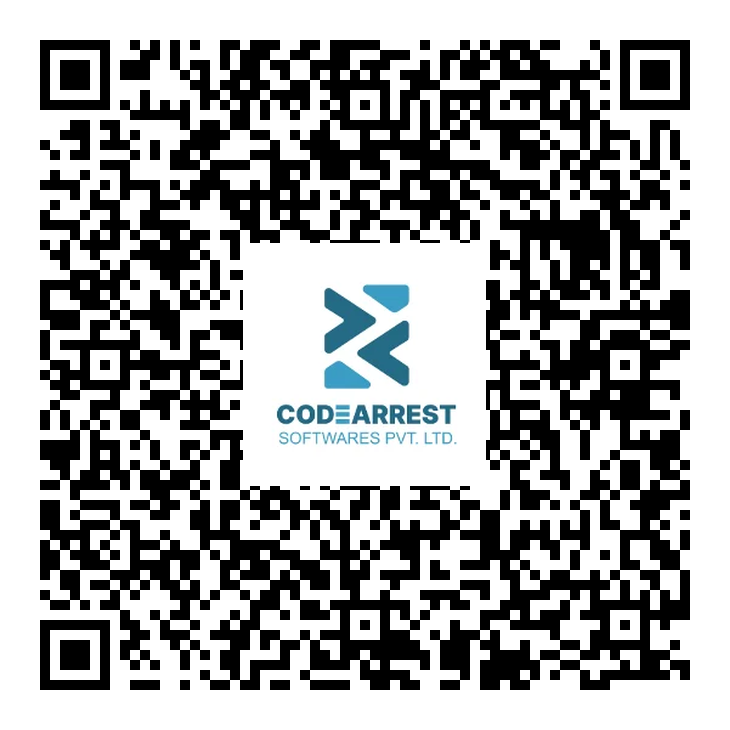

In [11]:
import qrcode
from PIL import Image
from IPython.display import display

# 1. THE PAYLOAD (CodeArrest vCard Format)
vcard_data = """BEGIN:VCARD
VERSION:3.0
ORG:CodeArrest Softwares PVT LTD;
EMAIL:sales@codearrest.com
URL:https://codearrest.com/
TEL:+917073899493
END:VCARD"""

# 2. THE MATRIX BUILDER (High Error Correction for Logo Injection)
qr = qrcode.QRCode(
    version=5, 
    error_correction=qrcode.constants.ERROR_CORRECT_H, 
    box_size=10,
    border=4,
)
qr.add_data(vcard_data)
qr.make(fit=True)

# 3. GENERATE BASE IMAGE
img_qr = qr.make_image(fill_color="black", back_color="white").convert('RGB')

# 4. BRANDING INJECTION (The Logo)
try:
    # Ensure your uploaded logo is named exactly this!
    logo = Image.open("codearrest_logo.png")
    
    # Calculate dimensions (Logo takes up 25% of the center)
    qr_width, qr_height = img_qr.size
    logo_size = int(qr_width / 3
                   )
    logo = logo.resize((logo_size, logo_size), Image.Resampling.LANCZOS)
    
    # Calculate center coordinates
    pos = ((qr_width - logo_size) // 2, (qr_height - logo_size) // 2)
    
    # Paste logo
    img_qr.paste(logo, pos)
    print("✅ CodeArrest Logo successfully injected!")

except FileNotFoundError:
    print("⚠️ Warning: 'codearrest_logo.webp' not found. Generated standard unbranded QR code.")

# 5. EXPORT AND DISPLAY
img_qr.save("CodeArrest_Contact_QR.png")
display(img_qr)